# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Tumor Screening Dashboard

### Scenario

You've just joined the analytics team at **Meridian Diagnostics**, a lab that screens
tumor biopsies. Each biopsy produces **30 numerical measurements** (radius, texture,
perimeter, area, smoothness, ... in mean/SE/worst variants) — far too many to eyeball in
a spreadsheet. The lead pathologist has given you a blunt brief:

1. *"I can't look at 30 numbers per patient and see anything. I need to SEE the data."*
2. *"Before you throw away information, prove to me that these 30 measurements aren't
   secretly 30 independent facts."*
3. *"Build me a 2D map of every patient. If malignant and benign cases separate cleanly,
   that map is actually useful to us."*
4. *"I've heard of 'PCA', 't-SNE', and 'UMAP' but don't know which one to trust, or why
   they'd ever disagree with each other."*

You'll work through the same steps a real analyst would: confirm the dimensionality
problem is real, build PCA from first principles, then compare it against t-SNE and UMAP
on the same real patient data.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset you'll be working with.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

np.random.seed(0)

df = pd.read_csv("Unit2_ppt4_breast_cancer.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
feature_cols = [c for c in df.columns if c not in ["id", "diagnosis"]]
X_raw = df[feature_cols].values
y = df["diagnosis"].values

print(f"Loaded {df.shape[0]} patients, {len(feature_cols)} measured dimensions.")
df[feature_cols[:5] + ["diagnosis"]].head()

Loaded 569 patients, 30 measured dimensions.


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,M
1,20.57,17.77,132.90,1326.0,0.08474,M
2,19.69,21.25,130.00,1203.0,0.10960,M
3,11.42,20.38,77.58,386.1,0.14250,M
4,20.29,14.34,135.10,1297.0,0.10030,M


## Task 1 — Prove the Dimensionality Problem Is Real (Complaint #1)

**Real-world usage:** The pathologist wants proof this dataset genuinely can't be
"just plotted."

**Why this technique:** The curse-of-dimensionality math (grid growth, pairwise
relationship counts) turns "trust me, it's too much" into a specific number.

**TODO:**
1. Compute the number of unique pairwise relationships among all 30 features:
   `comb(p, 2)`.
2. Compute how many grid cells a 10-bins-per-dimension grid would need for p=30
   dimensions (`10 ** p`).
3. Print both, with a one-line comment on what each number implies.

In [3]:
p = len(feature_cols)

# TODO 1: number of unique pairwise relationships among the 30 features
n_pairs = comb(p, 2)

# TODO 2: number of grid cells for a 10-bin-per-dimension grid at p=30
n_cells = 10 ** p

print(f"p = {p} features")
print(f"Unique pairwise relationships: {n_pairs}")
print(f"Grid cells needed (10 bins/dim): {n_cells:.2e}")

# Interpretation:
# 435 pairwise relationships are already too many to inspect individually,
# while a 30-dimensional 10-bin grid would require 10^30 cells.

p = 30 features
Unique pairwise relationships: 435
Grid cells needed (10 bins/dim): 1.00e+30


**Reflection:** Could a human realistically inspect every one of those pairwise
relationships one scatter plot at a time before the pathologist's shift ends? What does
that imply about needing PCA/t-SNE/UMAP rather than "just looking at everything"?

Ans:

No, realistically a human could not inspect all 435 pairwise relationships one scatter plot at a time before the pathologist's shift ends. This shows why dimensionality-reduction methods such as PCA, t-SNE, and UMAP are useful: they provide a lower-dimensional representation that makes the overall structure of the data easier to visualize and explore.

## Task 2 — Prove the 30 Measurements Aren't Independent (Complaint #2)

**Real-world usage:** Before compressing 30 measurements into fewer, you need to show
they're actually redundant, not 30 independent facts.

**Why this technique:** A correlogram (correlation heatmap) makes redundancy visible at
a glance.

**TODO:**
1. Compute the correlation matrix of `df[feature_cols]`.
2. Plot it as a heatmap (`plt.imshow`, `cmap="RdBu_r"`, `vmin=-1, vmax=1`).
3. Count how many feature pairs have `abs(correlation) > 0.9` (excluding the diagonal).

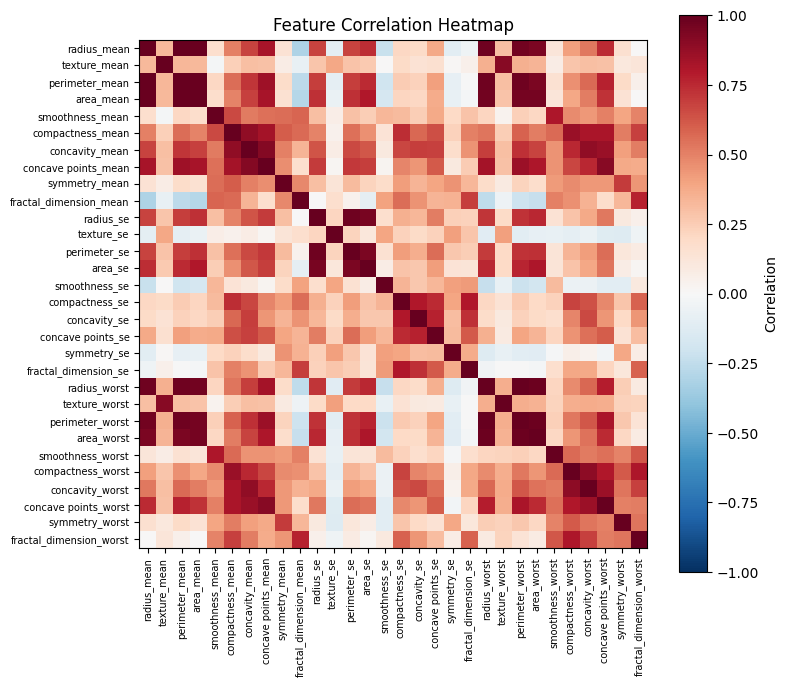

Highly correlated pairs (|r| > 0.9): 21


In [4]:
# TODO 1: correlation matrix
corr = df[feature_cols].corr()

# TODO 2: plot the heatmap
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(
    corr,
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))

ax.set_xticklabels(feature_cols, rotation=90, fontsize=7)
ax.set_yticklabels(feature_cols, fontsize=7)

ax.set_title("Feature Correlation Heatmap")

fig.colorbar(im, ax=ax, label="Correlation")

plt.tight_layout()
plt.show()

# TODO 3: count highly correlated pairs
# Use only the upper triangle so each pair is counted once.
upper_triangle = np.triu(
    np.ones(corr.shape, dtype=bool),
    k=1
)

high_corr_pairs = (
    np.abs(corr.values)[upper_triangle] > 0.9
).sum()

print("Highly correlated pairs (|r| > 0.9):", high_corr_pairs)

**Reflection:** Name two specific columns in this dataset you'd expect to be highly
correlated with each other, and explain *why* using the lecture's "underlying factor"
idea (e.g. tumor size).

Ans:

Radius mean and perimeter mean would be expected to be highly correlated because both measurements are strongly influenced by the underlying factor of tumor size. As the size of a tumor increases, both its radius and perimeter tend to increase. Therefore, these measurements contain related information rather than representing completely independent facts.

## Task 3 — Build PCA From Scratch (Complaint #3, part A)

**Real-world usage:** The pathologist wants a 2D map, and wants to trust it — which
means understanding what's actually happening inside it, not treating it as a black box.

**Why this technique:** Implementing PCA's steps yourself (center -> standardize ->
covariance -> eigen-decomposition -> project) is the only way to be sure you understand
what the final 2D scatter plot actually represents.

**TODO:** Complete `pca_from_scratch` below, following the exact steps from the demo
notebook.

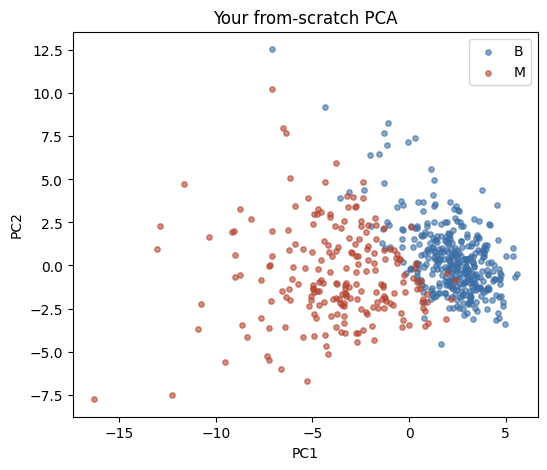

In [5]:
def pca_from_scratch(X, k):

    # TODO 1: center AND standardize X
    # subtract mean and divide by sample standard deviation (ddof=1)
    X_centered = X - np.mean(X, axis=0)
    X_scaled = X_centered / np.std(X, axis=0, ddof=1)

    # TODO 2: compute covariance matrix
    cov = np.cov(X_scaled, rowvar=False)

    # TODO 3: eigen-decompose covariance matrix
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort eigenvalues/eigenvectors in descending order
    order = np.argsort(eigvals)[::-1]

    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # TODO 4: keep top k eigenvectors and project
    top_eigvecs = eigvecs[:, :k]
    Z = X_scaled @ top_eigvecs

    return Z, eigvals, eigvecs


Z, eigvals, eigvecs = pca_from_scratch(X_raw, k=2)

fig, ax = plt.subplots(figsize=(6, 5))

for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax.scatter(
        Z[mask, 0],
        Z[mask, 1],
        s=15,
        alpha=0.6,
        color=color,
        label=label
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Your from-scratch PCA")
ax.legend()

plt.show()

**Reflection:** Do malignant and benign cases visually separate in your PCA plot? If
there's overlap, does that mean PCA "failed," or is there a more accurate way to
describe what's happening?

Ans:

The malignant and benign cases show substantial visual separation in the PCA plot, although some observations overlap. This does not mean PCA failed. PCA is an unsupervised dimensionality-reduction method that chooses directions of maximum variance without using the diagnosis labels, so its objective is to preserve variation in the measurements rather than explicitly separate malignant and benign cases.

## Task 4 — Choose k With Evidence, Not a Guess

**Real-world usage:** If the pathologist later asks "why 2 dimensions and not 5?", you
need a defensible answer.

**Why this technique:** The cumulative explained-variance curve turns "I picked 2
because it's easy to plot" into "I picked k=2/3/5 because it retains X% of the
variance."

**TODO:**
1. Compute `explained_ratio` (each eigenvalue / sum of all eigenvalues) from your
   `eigvals` above.
2. Compute the cumulative sum.
3. Find the smallest k that reaches >= 90% cumulative variance.

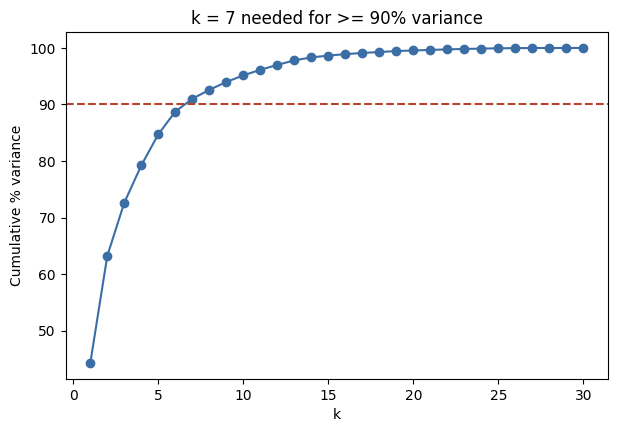

In [6]:
# TODO 1: explained variance ratio
explained_ratio = eigvals / eigvals.sum()

# TODO 2: cumulative variance
cumulative = np.cumsum(explained_ratio)

# TODO 3: smallest k reaching >= 90%
k_90 = np.argmax(cumulative >= 0.90) + 1

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(
    range(1, len(cumulative) + 1),
    cumulative * 100,
    "o-",
    color="#3b6ea5"
)
ax.axhline(90, color="#b5432e", ls="--")

ax.set_xlabel("k")
ax.set_ylabel("Cumulative % variance")
ax.set_title(f"k = {k_90} needed for >= 90% variance")

plt.show()

**Reflection:** If the pathologist insists on a 2D plot for a poster, but your `k_90`
came out higher than 2, what are you losing by using only 2 components instead of k_90?

Ans:

Using only 2 components means that we lose some of the information captured by the remaining principal components. In this case, 7 components are needed to preserve at least 90% of the variance, so a 2D plot captures only the first two major directions of variation. The 2D visualization is useful for presenting the data, but it is not a complete representation of the original 30-dimensional dataset. Therefore, some patterns and differences present in the other components may not be visible in the 2D plot.

## Task 5 — Compare PCA, t-SNE, and UMAP (Complaint #4)

**Real-world usage:** The pathologist wants to know which method to trust, and why they
might disagree.

**Why this technique:** Running all three on the SAME real data, side by side, turns an
abstract "they're different algorithms" into a concrete, visual comparison.

**TODO:**
1. Standardize `X_raw` using `StandardScaler`.
2. Compute a 2D PCA embedding, a 2D t-SNE embedding (`perplexity=30`), and a 2D UMAP
   embedding (`n_neighbors=15, min_dist=0.1`) — all with `random_state=0`.
3. Plot all three side by side, colored by `diagnosis`.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


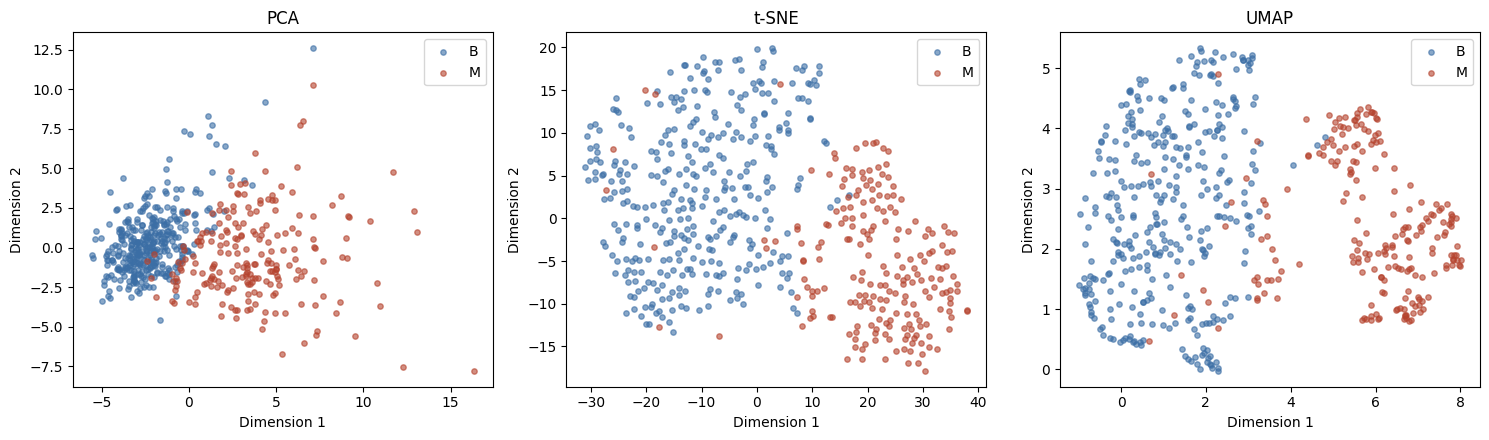

In [7]:
# TODO 1: standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# TODO 2: compute all three embeddings
pca_emb = PCA(n_components=2, random_state=0).fit_transform(X_scaled)

tsne_emb = TSNE(
    n_components=2,
    perplexity=30,
    random_state=0
).fit_transform(X_scaled)

umap_emb = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=0
).fit_transform(X_scaled)

# TODO 3: plot all three embeddings
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, emb, name in zip(
    axes,
    [pca_emb, tsne_emb, umap_emb],
    ["PCA", "t-SNE", "UMAP"]
):

    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label

        ax.scatter(
            emb[mask, 0],
            emb[mask, 1],
            s=15,
            alpha=0.6,
            color=color,
            label=label
        )

    ax.set_title(name)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
    ax.legend()

plt.tight_layout()
plt.show()

**Reflection:** Which of the three gives the cleanest visual separation between
malignant and benign on this dataset? Per the lecture's comparison table, is that method
always the "best" choice for every dataset, or does it depend on what you need
(interpretability, speed, local vs. global structure)?

Ans:

UMAP gives the cleanest visual separation between the benign and malignant cases in this dataset, with t-SNE also showing strong separation. PCA shows more overlap because it uses linear directions of maximum variance, while t-SNE and UMAP can capture nonlinear neighborhood structure. However, UMAP is not always the best method because the result can depend on parameters and the type of data being analyzed. PCA is generally more interpretable and computationally simpler, while t-SNE and UMAP are mainly useful for exploring complex nonlinear patterns.

## Task 6 — The Decision (No Code)

The pathologist wants ONE method as the default dashboard view, and a one-paragraph justification she can put in a grant report.

**Reflection (final):** Write a 4–6 sentence recommendation. Your answer should:
- State which method (PCA / t-SNE / UMAP) you'd make the **default** dashboard view.
- Justify it using at least one specific idea from the lecture (e.g. PCA's interpretable linear axes vs. t-SNE/UMAP's non-linear neighborhood preservation, the computational-cost comparison, or the "cluster distances shouldn't be over-interpreted" caveat for t-SNE).
- Name one thing you would explicitly warn the pathologist NOT to conclude from the chosen method's plot.

_Your final recommendation here:_

I would choose UMAP as the default dashboard view because it provides the clearest visual separation between benign and malignant cases in this dataset. Unlike PCA, which uses linear directions of maximum variance, UMAP can preserve nonlinear neighborhood structure and therefore reveal patterns that may not appear clearly in a linear projection. UMAP is useful for exploratory visualization, although its results can depend on parameters and should be interpreted carefully. I would explicitly warn the pathologist not to conclude that the separated clusters prove that UMAP can diagnose whether a tumor is malignant or benign. The plot shows patterns in the measured data, but it is not itself a diagnostic or predictive model.